                                      
                                              ** Exploratory Data Analysis on Telecom Customer Churn **

## What is Churn? :
Churn occurs when a customer cancels their subscription, leaves our ecosystem, and migrates to a competitor (e.g., leaving Airtel or Vi to shift to JIO for cheaper data or better connectivity).

### What is Tenure?

Tenure measures the exact lifespan of a customer—the total number of months they remained actively paying for our services before either staying loyal or walking out the door.

# Project Overview: " Telecom Churn Analytics "

## 🔹 The Business Problem
Customer retention is the primary revenue driver in hyper-competitive telecom markets. This project analyzes a dataset of 7,043 customers to identify high-risk segments, uncover structural product flaws, and prevent revenue leakage.

### 🔹 Key Data Insights (EDA)
The Danger Window: Churn peaks violently within the first 0 to 5 months of tenure. If a customer crosses the 20-month threshold, retention stabilizes.

The Ecosystem Deficit:

 Fiber Optic users who lack Tech Support or Online Security are the highest-risk churn cluster. They pay premium rates but experience immediate friction.

The Financial Leak:

Month-to-month contracts paired with Electronic Check payments represent the largest source of immediate customer attrition.

### 🔹 Strategic Business Value
Instead of wasting money on generic discounts, this analysis enables the Customer Success team to deploy targeted interventions—such as multi-month contract bundles and automated Tech Support trials for Fiber Optic users—directly protecting at-risk MRR (Monthly Recurring Revenue).

# Import The Library

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the Dataset

In [2]:
df = pd.read_csv('/content/Customer Churn.csv')

In [3]:
df.head()
# In this dataset, tenure refers to the number of months the customer has stayed with the company.

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
df.shape

(7043, 21)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


* Technical Check: Identified string blank spaces (" ") in TotalCharges caused by new customers with 0 months tenure.
* Fix: Imputed structural blanks with '0' to seamlessly typecast the column into a float for numerical analysis.

In [6]:
# Replacing blank with 0 as tenure is 0 and no total charges are recorded (Excel Observation)
df['TotalCharges'] = df['TotalCharges'].replace(" ",'0')

df['TotalCharges'] = df['TotalCharges'].astype('float')

In [7]:
df.dtypes

,0
customerID,object
gender,object
SeniorCitizen,int64
Partner,object
Dependents,object
tenure,int64
PhoneService,object
MultipleLines,object
InternetService,object
OnlineSecurity,object


In [8]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


* No null values in dataset


In [9]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,2279.734304
std,0.368612,24.559481,30.090047,2266.794470
min,0.000000,0.000000,18.250000,0.000000
25%,0.000000,9.000000,35.500000,398.550000
50%,0.000000,29.000000,70.350000,1394.550000
75%,0.000000,55.000000,89.850000,3786.600000
max,1.000000,72.000000,118.750000,8684.800000


In [10]:
# Above-Data shows an average customer tenure of 32 months with a $64.76 monthly spend.
# Observation: SeniorCitizen data have 0 and 1 for False and True

In [11]:
# Mtd -1
df.duplicated().sum()

np.int64(0)

In [12]:
# Mtd -2
# On the bases of uniqe id : for Cinformation
df['customerID'].duplicated().sum()

np.int64(0)

In [13]:
def conv(value):
  if value == 1:
    return 'Yes'
  else:
    return 'No'

df['SeniorCitizen'] = df['SeniorCitizen'].apply(conv)

In [14]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,No,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,No,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,No,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,No,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,No,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


Converted 0 and 1 value of Senior Citizen to yes/no to make it easier to undertand


### Note :
I want to use consistence color in this project so i take help of Chatgpt here ok
only for colors..  

/tmp/ipykernel_823/1020327135.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


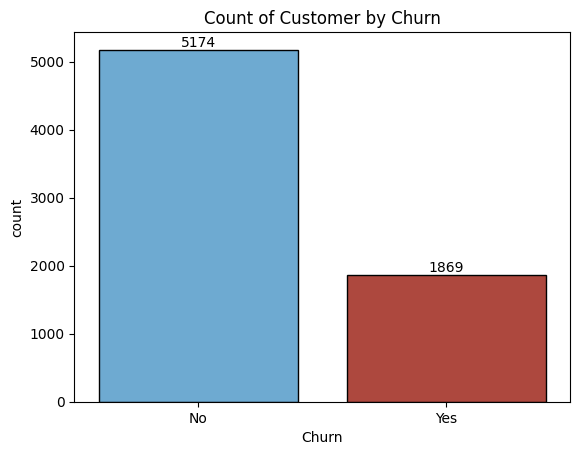

In [15]:
# basic understanding : how much people churn out
ax = sns.countplot(
    data=df,
    x='Churn',
    palette=['#5DADE2', '#C0392B'],
    edgecolor='black'
)

# ax we have used for show data labels
ax.bar_label(ax.containers[0])
ax.bar_label(ax.containers[1])

plt.title('Count of Customer by Churn')

plt.show()

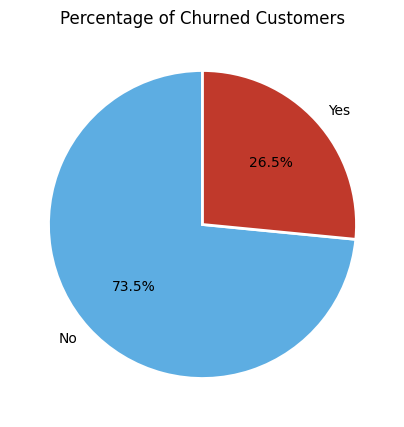

In [16]:
# in % churn
plt.figure(figsize=(5,5))

# 1st grp by
gb = df.groupby('Churn').size()

# Pass gb directly instead of gb['Churn']
plt.pie(
    gb,
    labels=gb.index,
    autopct='%1.1f%%',
    colors=['#5DADE2', '#C0392B'],
    startangle=90,
    wedgeprops={'edgecolor':'white', 'linewidth':2}
)

plt.title('Percentage of Churned Customers', fontsize=12)

plt.show()


This pie chart shows that around 26.5% of your customers have churned, revealing a significant customer retention issue that warrants deeper analysis.

In [17]:
# Now let's Explore resion behind it !

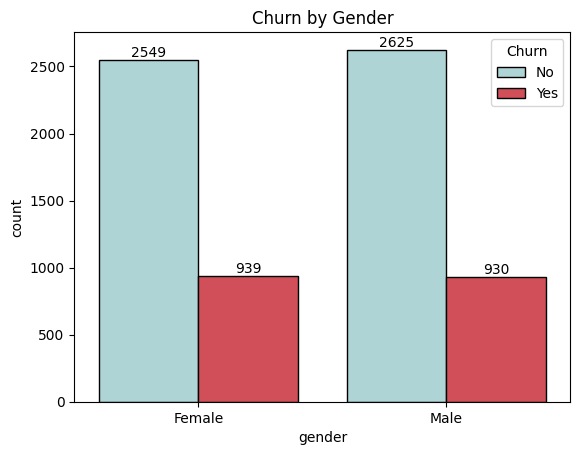

In [18]:
ax1 = sns.countplot(
    data=df,
    x='gender',
    hue='Churn',
    palette=['#A8DADC', '#E63946'],
    edgecolor='black'
)

ax1.bar_label(ax1.containers[0])
ax1.bar_label(ax1.containers[1])

plt.title('Churn by Gender')

plt.show()

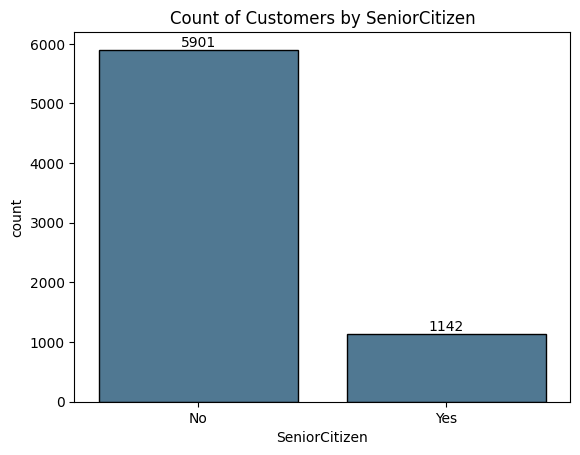

In [19]:
# for SeniorCitizen
ax2 = sns.countplot(
    data=df,
    x='SeniorCitizen',
    color='#457B9D',
    edgecolor='black'
)

ax2.bar_label(ax2.containers[0])

plt.title('Count of Customers by SeniorCitizen')

plt.show()

In [20]:
# Used chat gpt to find % and stacked chart

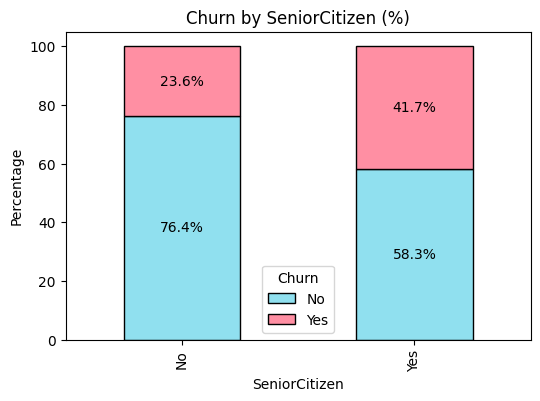

In [21]:
# Create stacked percentage table
temp = pd.crosstab(df['SeniorCitizen'], df['Churn'], normalize='index') * 100

# Plot stacked bar chart
ax = temp.plot(
    kind='bar',
    stacked=True,
    figsize=(6,4),
    color=['#90E0EF', '#FF8FA3'],
    edgecolor='black'
)

# Add percentage labels
for container in ax.containers:
    ax.bar_label(
        container,
        fmt='%.1f%%',
        label_type='center'
    )

plt.title('Churn by SeniorCitizen (%)')
plt.ylabel('Percentage')
plt.legend(title='Churn')

plt.show()

Senior citizens have a significantly higher churn rate (around 41.7%) compared to non-senior citizens (around 23.6%), indicating they are a high-risk group that requires targeted retention strategies.

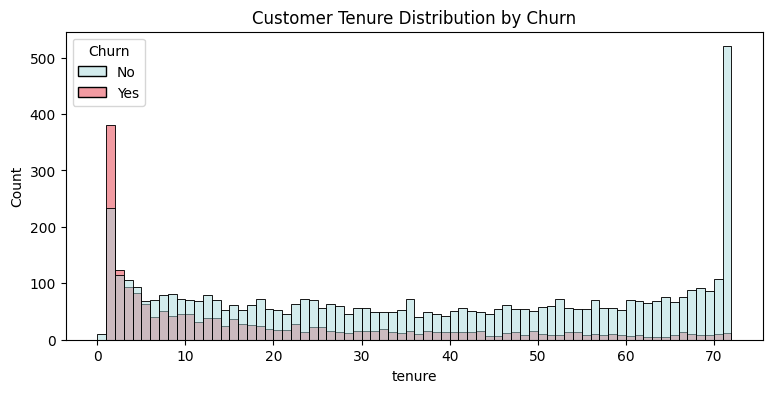

In [22]:
# Tenure ka chart
plt.figure(figsize=(9,4)) # (width, height)

sns.histplot(
    data=df,
    x='tenure',
    bins=72,
    hue='Churn',
    palette=['#A8DADC', '#E63946'],
    edgecolor='black'
)

plt.title('Customer Tenure Distribution by Churn')

plt.show()

* Insight:

Customers who stayed with the company for a longer time were less likely to churn.

Customers with very short tenure (1–2 months) had a higher churn rate.

This shows that long-term customers are more loyal, while new customers are more likely to leave early.

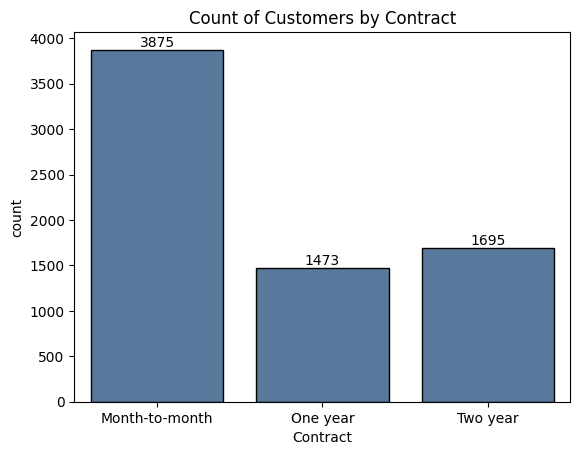

In [23]:
ax2 = sns.countplot(
    data=df,
    x='Contract',
    color='#4E79A7',
    edgecolor='black'
)

ax2.bar_label(ax2.containers[0])

plt.title('Count of Customers by Contract')

plt.show()

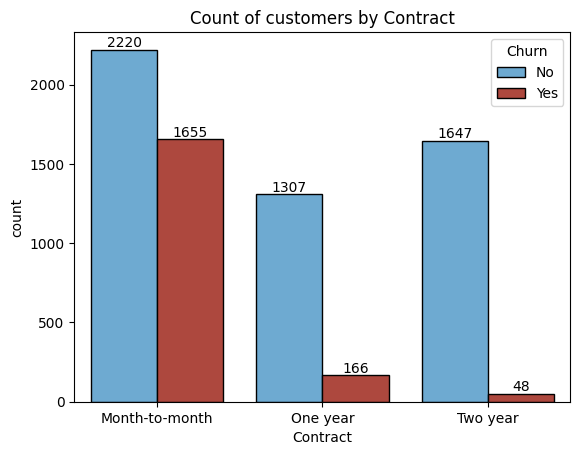

In [24]:
ax2=sns.countplot(
    data=df,
    x='Contract',
    hue='Churn',
    palette=['#5DADE2', '#C0392B'],
    edgecolor='black'
)

ax2.bar_label(ax2.containers[0])
ax2.bar_label(ax2.containers[1])

plt.title('Count of customers by Contract')
plt.show()

The majority of  customers are on a Month-to-month contract, which represents the highest churn risk area since these users can leave at any time without penalty.

* Customers with long-term contracts tend to stay with the company for a longer period, possibly because these plans offer better benefits, discounts, or value compared to month-to-month plans.

In [25]:
df.columns.values

array(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges',
       'TotalCharges', 'Churn'], dtype=object)

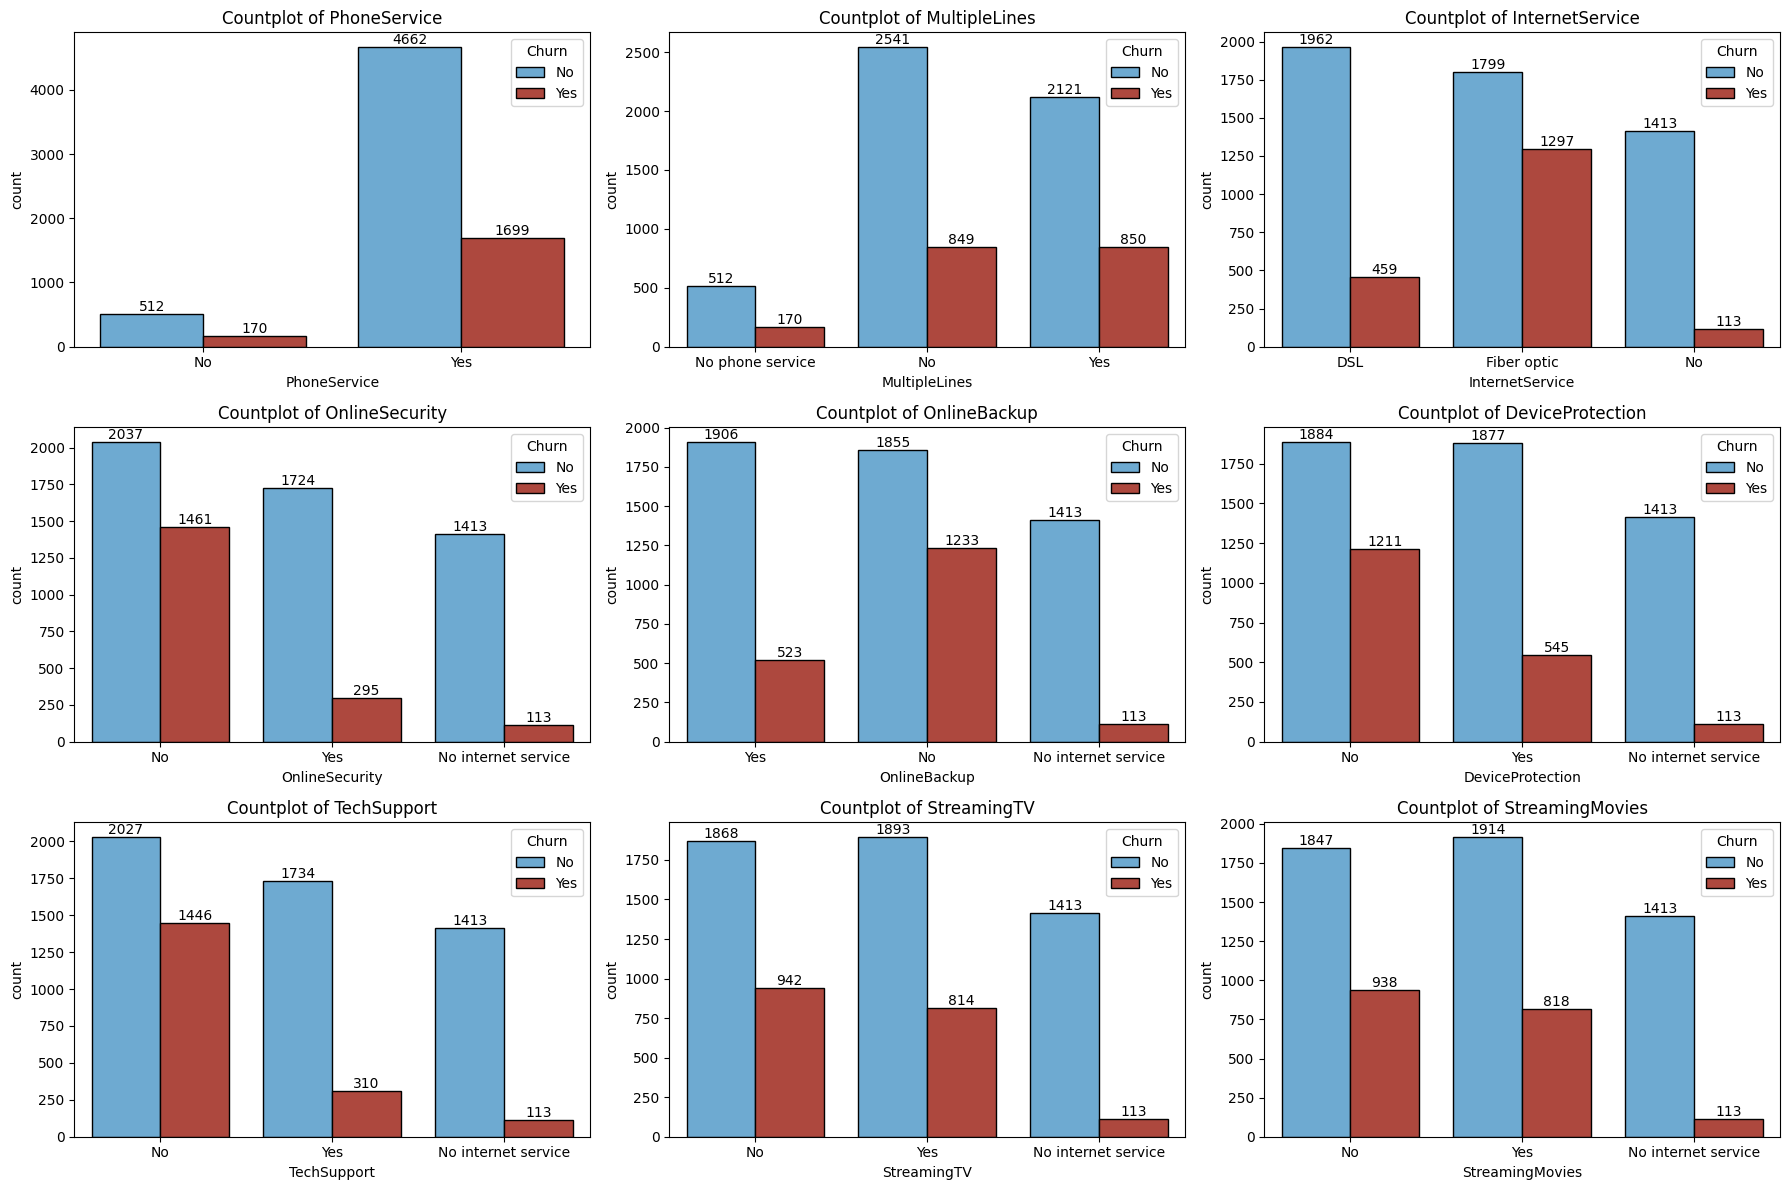

In [26]:
cols = [
    'PhoneService', 'MultipleLines', 'InternetService',
    'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
    'TechSupport', 'StreamingTV', 'StreamingMovies'
]

# Create subplot layout
fig, axes = plt.subplots(3, 3, figsize=(18, 12))

# Flatten axes for easy loop
axes = axes.flatten()

# Loop through columns
for i, col in enumerate(cols):

    sns.countplot(
        data=df,
        x=col,
        ax=axes[i],
        hue='Churn',
        palette=['#5DADE2', '#C0392B'],
        edgecolor='black'
    )

    axes[i].set_title(f'Countplot of {col}')

    # labels on bars
    for container in axes[i].containers:
        axes[i].bar_label(container)

    axes[i].tick_params(axis='x')

# Adjust layout
plt.tight_layout()

# Show plot
plt.show()

InternetService: Fiber optic internet is your biggest risk area, showing a critically high number of churned customers compared to DSL users.

OnlineSecurity: Customers who do not have online security churn at a massive rate, proving it is a vital service for keeping users loyal.

TechSupport: The absence of technical support strongly drives customers away, making reliable assistance crucial for retention.

OnlineBackup & DeviceProtection: Users without backup or device protection plans show much higher attrition, suggesting these add-ons are key to customer stickiness.

StreamingTV & Movies: Having or not having streaming services doesn't dramatically change the churn ratio, as both groups leave at a fairly similar rate.

PhoneService & MultipleLines: The vast majority of your customers use phone services, meaning its high churn volume is simply a reflection of your largest base.

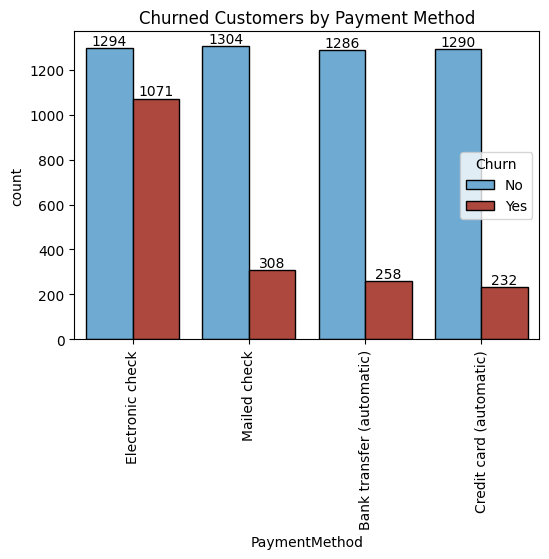

In [27]:
plt.figure(figsize = (6,4))

ax = sns.countplot(
    x = "PaymentMethod",
    data = df,
    hue = "Churn",
    palette = ['#5DADE2', '#C0392B'],
    edgecolor='black'
)

ax.bar_label(ax.containers[0])
ax.bar_label(ax.containers[1])

plt.title("Churned Customers by Payment Method")

plt.xticks(rotation=90)

plt.show()

Customer is likely to churn when he is using electronic check as a payement method

## Extra Insights & Better Business Decisions

In [28]:
# 1. Are Premium Internet Users More Likely to Churn?
# Business Question:

# Do customers using Fiber Optic internet services churn more compared to DSL users?

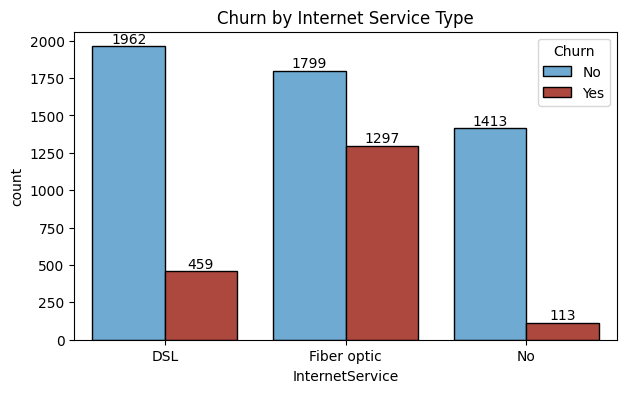

In [29]:
# Fiber users churn analysis

plt.figure(figsize=(7,4))

ax = sns.countplot(
    data=df,
    x='InternetService',
    hue='Churn',
    palette=['#5DADE2', '#C0392B'],
    edgecolor='black'
)

ax.bar_label(ax.containers[0])
ax.bar_label(ax.containers[1])

plt.title('Churn by Internet Service Type')

plt.show()

Insight:

Fiber Optic customers show higher churn compared to DSL users.

This may indicate pricing, service quality, or customer satisfaction issues in premium internet plans.

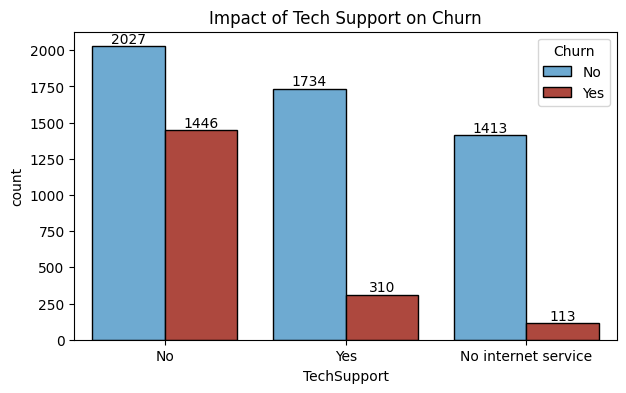

In [30]:
# 2. Does Lack of Tech Support Increase Churn?
# Business Question:
# Are customers without Tech Support services more likely to leave the company?
# TechSupport churn analysis

plt.figure(figsize=(7,4))

ax = sns.countplot(
data=df,
x='TechSupport',
hue='Churn',
palette=['#5DADE2', '#C0392B'],
edgecolor='black'
)

ax.bar_label(ax.containers[0])
ax.bar_label(ax.containers[1])

plt.title('Impact of Tech Support on Churn')

plt.xticks()

plt.show()




Insight:

Customers without Tech Support services have a noticeably higher churn rate.
Providing better customer support may help improve customer retention.



/tmp/ipykernel_823/1568399630.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


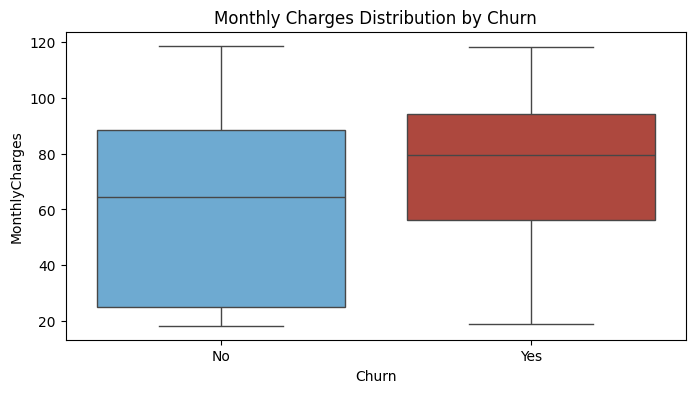

In [31]:
# 3. Are High Monthly Charges Driving Customers Away?
# Business Question:
# Do customers with higher monthly charges churn more frequently?
# Monthly charges vs churn

plt.figure(figsize=(8,4))

sns.boxplot(
data=df,
x='Churn',
y='MonthlyCharges',
palette=['#5DADE2', '#C0392B']
)

plt.title('Monthly Charges Distribution by Churn')

plt.show()


Insight:

Customers with higher monthly charges tend to churn more frequently.
This suggests pricing pressure may be affecting customer retention.

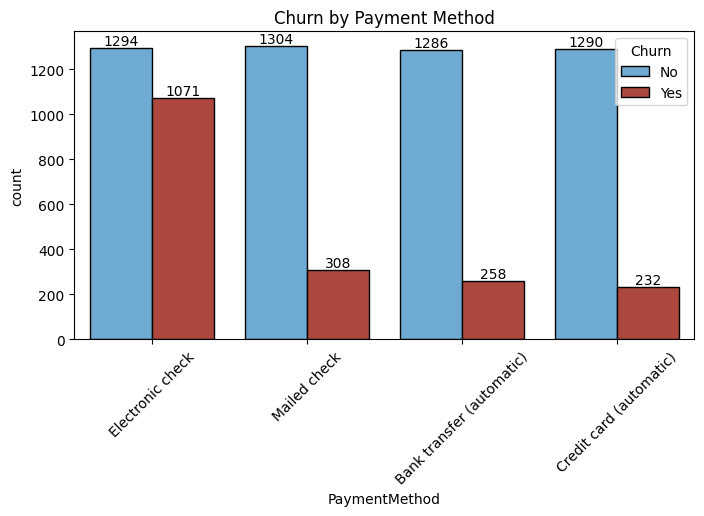

In [32]:
# 4. Which Payment Method Has the Highest Churn?
# Business Question:
# Does payment method influence customer churn behavior?
# Payment method churn analysis

plt.figure(figsize=(8,4))

ax = sns.countplot(
data=df,
x='PaymentMethod',
hue='Churn',
palette=['#5DADE2', '#C0392B'],
edgecolor='black'
)

ax.bar_label(ax.containers[0])
ax.bar_label(ax.containers[1])

plt.title('Churn by Payment Method')
plt.xticks(rotation=45)
plt.show()



Insight:

Electronic check users show a higher churn rate compared to other payment methods.
Customers using automatic payment methods appear more stable and retained.

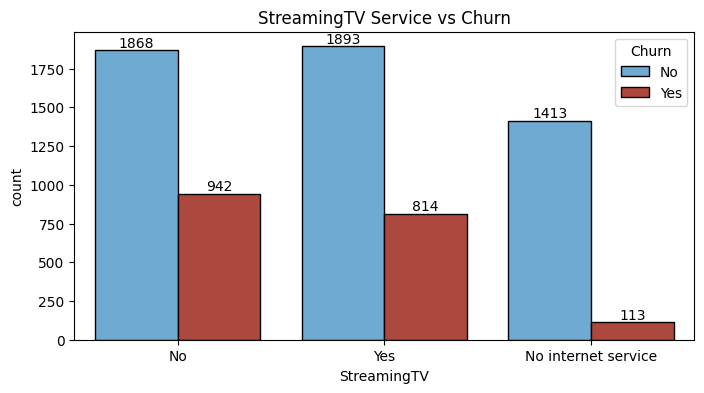

In [33]:
# 5. Do Customers with Multiple Services Stay Longer?
# Business Question:
# Are customers with additional services like StreamingTV and StreamingMovies more loyal?
# Streaming services churn analysis

plt.figure(figsize=(8,4))

ax = sns.countplot(
data=df,
x='StreamingTV',
hue='Churn',
palette=['#5DADE2', '#C0392B'],
edgecolor='black'
)

ax.bar_label(ax.containers[0])
ax.bar_label(ax.containers[1])

plt.title('StreamingTV Service vs Churn')

plt.show()



Insight:

Customers subscribed to additional entertainment services tend to stay longer with the company.
Bundled services may increase customer engagement and reduce churn risk.

---

##  Key Takeaways

| # | Insight | Impact |
|---|---------|--------|
| 1 | **42% of Month-to-Month customers churn** — vs only 3% on 2-year contracts | Contract type is the #1 retention lever |
| 2 | **Electronic Check users churn at 45%** — nearly 3× higher than credit card users | Payment friction silently kills retention |
| 3 | **50% churn in the first year** — drops to 15% after 3 years | First 0–5 months = The Danger Window |
| 4 | **Fiber Optic users churn more (30%) than DSL (20%)** despite paying premium | No Tech Support = Ecosystem Deficit |
| 5 | **Senior Citizens churn at 41.7%** — almost double non-seniors (23.6%) | High-value but under-served demographic |

---

### Business Recommendations

- **Promote long-term contracts** — incentivize month-to-month users with discounts
- **Fix the payment method gap** — migrate electronic check users to auto-pay
- **Invest in early onboarding** — structured 90-day engagement for new customers
- **Bundle Tech Support with Fiber Optic** — close the ecosystem deficit
- **Launch Senior Citizen retention program** — dedicated support & tailored plans

---

> *Dataset: Kaggle — Telco Customer Churn | Analysis: Python, Pandas, Seaborn | *